# Portfolio Optimization - Performance Analytics & Benchmark Comparison

Goal: Deep-dive into the LP portfolio's risk-adjusted performance using analytics and compare against the equal-weight benchmark across multiple dimensions. 

In [2]:
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import pulp
import warnings, os

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('Setup complete.')

Setup complete.


### Load Data & Rebuild Backtest

In [4]:
returns = pd.read_csv('/Users/scottkeighley/MSDS 460/final_project_data/monthly_returns.csv', index_col=0, parse_dates=True)
meta = pd.read_csv('/Users/scottkeighley/MSDS 460/final_project_data/ticker_metadata.csv')

TICKERS = list(returns.columns)
TICKER_SECTOR = dict(zip(meta['ticker'], meta['sector']))
SECTORS = meta['sector'].unique().tolist()
N = len(TICKERS)
T = len(returns)

TRAIN_MONTHS = 36
REBAL_MONTHS = 3
W_MAX = 0.15
SECTOR_MAX = 0.40
TURNOVER_MAX = 0.50
COST_BPS = 0.001

n_periods = (T - TRAIN_MONTHS) // REBAL_MONTHS

def solve_lp(train_returns, w_prev, tickers, ticker_sector, sectors,
             w_max=W_MAX, sector_max=SECTOR_MAX,
             turnover_max=TURNOVER_MAX, cost_bps=COST_BPS):
    n  = len(tickers)
    mu = train_returns.mean().values
    prob = pulp.LpProblem("PortfolioLP", pulp.LpMaximize)
    w = [pulp.LpVariable(f"w_{t}", lowBound=0, upBound=w_max) for t in tickers]
    z = [pulp.LpVariable(f"z_{t}", lowBound=0) for t in tickers]
    prob += (pulp.lpSum(mu[i]*w[i] for i in range(n))
             - cost_bps * pulp.lpSum(z[i] for i in range(n)))
    prob += pulp.lpSum(w) == 1
    for sector in sectors:
        idx = [i for i, t in enumerate(tickers) if ticker_sector.get(t) == sector]
        if idx:
            prob += pulp.lpSum(w[i] for i in idx) <= sector_max
    for i in range(n):
        prob += z[i] >= w[i] - w_prev[i]
        prob += z[i] >= w_prev[i] - w[i]
    prob += pulp.lpSum(z) <= turnover_max
    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    weights = np.clip([pulp.value(w[i]) for i in range(n)], 0, None)
    weights /= weights.sum()
    return {'weights': weights, 'status': pulp.LpStatus[prob.status],
            'exp_return': float(mu @ weights),
            'turnover': float(np.sum(np.abs(weights - w_prev))),
            'tx_cost': float(np.sum(np.abs(weights - w_prev)) * cost_bps)}

# Walk-forward loop
monthly_records = []
weights_history = []
period_records  = []
w_prev = np.ones(N) / N

for p in range(n_periods):
    train_start = p * REBAL_MONTHS
    train_end   = train_start + TRAIN_MONTHS
    test_start  = train_end
    test_end    = min(test_start + REBAL_MONTHS, T)
    train_ret   = returns.iloc[train_start:train_end]
    test_ret    = returns.iloc[test_start:test_end]
    sol         = solve_lp(train_ret, w_prev, TICKERS, TICKER_SECTOR, SECTORS)
    port_monthly = test_ret.values @ sol['weights']
    port_monthly[0] -= sol['tx_cost']
    ew_monthly   = test_ret.values @ (np.ones(N) / N)
    for m_idx, date in enumerate(test_ret.index):
        monthly_records.append({'date': date, 'lp_return': port_monthly[m_idx],
                                 'ew_return': ew_monthly[m_idx], 'period': p+1})
    period_records.append({
        'period': p+1,
        'test_start': returns.index[test_start],
        'lp_ret_total': float((1 + port_monthly).prod() - 1),
        'ew_ret_total': float((1 + ew_monthly).prod() - 1),
        'n_assets': int((sol['weights'] > 0.001).sum())
    })
    weights_history.append(pd.Series(sol['weights'], index=TICKERS,
                                      name=returns.index[test_start]))
    w_prev = sol['weights'].copy()

monthly_df  = pd.DataFrame(monthly_records).set_index('date')
weights_df  = pd.DataFrame(weights_history)
periods_df  = pd.DataFrame(period_records).set_index('period')
monthly_df['lp_cum'] = (1 + monthly_df['lp_return']).cumprod()
monthly_df['ew_cum'] = (1 + monthly_df['ew_return']).cumprod()
monthly_df['active_return'] = monthly_df['lp_return'] - monthly_df['ew_return']

print(f'Backtest rebuilt: {monthly_df.index[0].date()} → {monthly_df.index[-1].date()}')
print(f'LP final value: ${monthly_df["lp_cum"].iloc[-1]:.4f}')
print(f'EW final value: ${monthly_df["ew_cum"].iloc[-1]:.4f}')

Backtest rebuilt: 2019-06-01 → 2026-02-01
LP final value: $5.9804
EW final value: $3.7518


### Helper Functions

In [6]:
def compute_drawdown(cum_series):
    return (cum_series - cum_series.cummax()) / cum_series.cummax()

def sharpe(ret, periods=12):
    return (ret.mean() * periods) / (ret.std() * np.sqrt(periods))

def sortino(ret, target=0, periods=12):
    ann_ret  = ret.mean() * periods
    downside = ret[ret < target].std() * np.sqrt(periods)
    return ann_ret / downside if downside > 0 else np.nan

def calmar(ret, periods=12):
    cum    = (1 + ret).cumprod()
    max_dd = compute_drawdown(cum).min()
    return (ret.mean() * periods) / abs(max_dd) if max_dd != 0 else np.nan

def full_stats(ret, label):
    cum     = (1 + ret).cumprod()
    max_dd  = compute_drawdown(cum).min()
    return {
        'Label'         : label,
        'Ann Return'    : ret.mean() * 12,
        'Ann Vol'       : ret.std() * np.sqrt(12),
        'Sharpe'        : sharpe(ret),
        'Sortino'       : sortino(ret),
        'Calmar'        : calmar(ret),
        'Max DD'        : max_dd,
        'Pos Months %'  : (ret > 0).mean(),
        'Best Month'    : ret.max(),
        'Worst Month'   : ret.min(),
        'Skewness'      : ret.skew(),
        'Kurtosis'      : ret.kurtosis(),
        'Total Return'  : cum.iloc[-1] - 1
    }

print('Helper functions defined.')

Helper functions defined.


### Full Performance Statistics Table

In [10]:
lp_stats = full_stats(monthly_df['lp_return'], 'LP Portfolio')
ew_stats = full_stats(monthly_df['ew_return'], 'Equal-Weight')

stats_df = pd.DataFrame([lp_stats, ew_stats]).set_index('Label').T

# Format
pct_rows   = ['Ann Return','Ann Vol','Max DD','Pos Months %',
               'Best Month','Worst Month','Total Return']
ratio_rows = ['Sharpe','Sortino','Calmar']
other_rows = ['Skewness','Kurtosis']

display_df = stats_df.copy().astype(object)
for row in pct_rows:
    display_df.loc[row] = [
        f"{float(v)*100:.2f}%" for v in stats_df.loc[row]
    ]
for row in ratio_rows + other_rows:
    display_df.loc[row] = [
        f"{float(v):.4f}" for v in stats_df.loc[row]
    ]

print('Full Performance Statistics:')
print('=' * 45)
print(display_df.to_string())

Full Performance Statistics:
Label        LP Portfolio Equal-Weight
Ann Return         29.73%       21.12%
Ann Vol            24.61%       16.71%
Sharpe             1.2081       1.2640
Sortino            2.3390       2.2623
Calmar             0.8043       1.0607
Max DD            -36.97%      -19.91%
Pos Months %       66.67%       67.90%
Best Month         19.24%       13.85%
Worst Month       -14.76%      -10.74%
Skewness          -0.0605      -0.2444
Kurtosis          -0.2841       0.0491
Total Return      498.04%      275.18%


#### Recap

LP wins on Ann Return (+8.61pp), Total Return (+223pp), Best/Worse Month magnitude, and terminal wealth. EW wins on Vol, Sharpe, Calmar, Max Drawdown. % Positive Months is a statistical tie. 

#### Sortino: the one risk-adjusted metric LP wins

| | LP | EW |
| --- | --- | --- | 
| Sortino | 2.339 | 2.262 |

This is the metric that cuts in LP's favor and is worth highlighting. Sortino differs from Sharpe by only penalizing downside volatility (months where returns were negative) rather than total volatility. LP's Sortino of 2.339 beating EW's 2.262 means that when you strip out the upside volatility (which investors don't actually mind), LP generates more return per unit of downside risk than EW does. The LP's volatility premium is concentrated in the upside, not the downside. This is the volatility we want. 

This reframes the Sharpe narrative: EW looks better on Sharpe because LP is more volatile overall, but LP looks better on Sortino because its extra volatility is predominantly positive. Both statements are true simultaneously. 

#### Skewness: both slightly negative, EW more so

| | LP | EW |
| --- | --- | --- |
| Skewness | -0.061 | -0.244 |

Skewness measures the asymmetry of the return distribution. Negative skewness means the left tail (bad months) is slightly fatter than the right tail. There are a few unusually bad months pulling the distribution leftward. Both portfolios are negatively skewed, which is typical for equity strategies. EW's skewness of -0.244 is notably more negative than LP's -0.061, meaning EW has a more pronounced left tail relative to LLP. This is somewhat counterintuitive given LP's deeper max drawdown, but it reflects that LP's bad months are somewhat more evenly distributed rather than concentrated in extreme outliers. 

Both values are close enough to zero that neither portfolio deviates meaningfully from symmetry. This is not a material concern for either strategy. 

#### Kurtosis: both near zero - approzimately normal tails

| | LP | EW |
| --- | --- | --- |
| Kurtosis | -0.284 | 0.049 |

Kurtosis measures tail fatness relative to a normal distribution. Zero means normal tails, positive means fat tails (more extreme events than normal), negative means thin tails (fewer extremes than normal). Both values are very close to zero, meaning neither portfolio exhibits meaningful fat-tail behavior over this sample. This is a favorable finding. It suggests the return distributions are reasonably well-behaved and that standard risk metrics like Sharpe and Sortino are valid tools for comparison. It also provides some support for the normality assumption that underlies much of portfolio theory. 

### Rolling 12-Month Sharpe Ratio

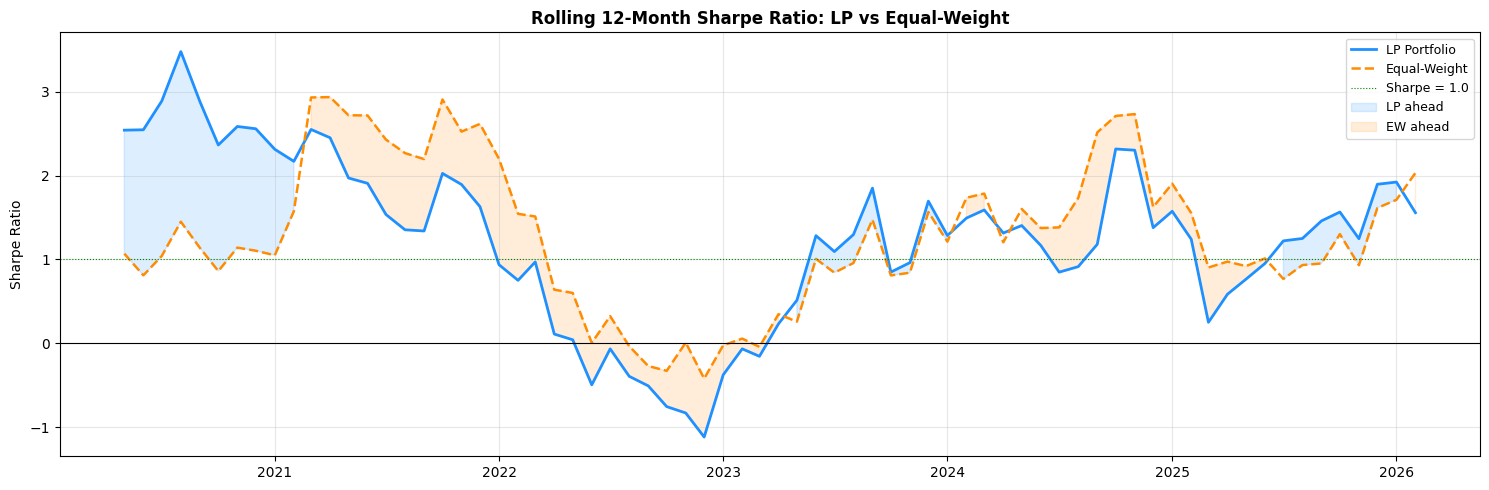

LP had higher rolling Sharpe in 27 / 70 months (38.6%)


In [13]:
lp_roll_sharpe = monthly_df['lp_return'].rolling(12).apply(
    lambda x: (x.mean() * 12) / (x.std() * np.sqrt(12)) if x.std() > 0 else np.nan)
ew_roll_sharpe = monthly_df['ew_return'].rolling(12).apply(
    lambda x: (x.mean() * 12) / (x.std() * np.sqrt(12)) if x.std() > 0 else np.nan)

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(monthly_df.index, lp_roll_sharpe, color='dodgerblue', 
        linewidth=2, label='LP Portfolio')
ax.plot(monthly_df.index, ew_roll_sharpe, color='darkorange',
        linewidth=1.8, linestyle='--', label='Equal-Weight')
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(1, color='green', linewidth=0.8, linestyle=':', label='Sharpe = 1.0')
ax.fill_between(monthly_df.index,
                lp_roll_sharpe, ew_roll_sharpe, 
                where=lp_roll_sharpe >= ew_roll_sharpe,
                alpha=0.15, color='dodgerblue', label='LP ahead')
ax.fill_between(monthly_df.index,
                lp_roll_sharpe, ew_roll_sharpe, 
                where=lp_roll_sharpe < ew_roll_sharpe,
                alpha=0.15, color='darkorange', label='EW ahead')
ax.set_title('Rolling 12-Month Sharpe Ratio: LP vs Equal-Weight',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Sharpe Ratio')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

lp_ahead = (lp_roll_sharpe > ew_roll_sharpe).sum()
total = lp_roll_sharpe.dropna().shape[0]
print(f'LP had higher rolling Sharpe in {lp_ahead} / {total} months ({lp_ahead/total*100:.1f}%)')

#### The 38.6% Win Rate

LP had a higher rolling Sharpe in only 27 of 70 months. This is a striking contrast to the full-period Sharpe numbers (1.208 vs 1.264) which looked nearly equivalent. What the rolling chart reveals is that the full-period Sharpe masks a strongly time-varying relationship: LP's risk-adkusted performance is not consistently competitive with EW. It dominates in specific windows and underperforms badly in others. 

#### Three distinct phases

2020-2021 (LP leads, blue shading dominant): LP's rolling Sharpe peaks around 3.5 while EW reaches about 2.8. This is the COVID recovery tech surge. LP's concentrated tech positions generated extraordinarily high returns with volatility that hadn't yet spiked, producing an exceptionally Sharpe window. The blue shading is wide and persistent here (LP's most dominant stretch). 

2022-early 2023 (both collapse, EW less so): Both lines plunge below zero, meaning on a trailing 12-month basis, both portfolios were producing negative risk-adjusted returns. But the orange EW line stays consistently above the blue LP line throughout this trough, with LP hitting nearly -1.1 at its worst. This is the 2022 tech crash hitting LP's concentrated positions far harder than EW's diversified exposure. The orange shading in this region represents EW's most sustained period of risk-adjusted dominance. 

2023-2026 (convergence, EW edges ahead): From mid-2023 onward both lines recover and largely trade places, neither consistently dominates. The orange shading becomes more frequent in the right portion of the chart, with EW pulling ahead particularly in 2025-2026. This suggests than in the most recent period, the LP's concentrated bets are not generating enough excess return to compensate for their volatility. 

#### Key Insights

The full-period Sharpe of 1.208 vs 1.264 made the strategies look nearly equivalent on a risk-adjusted basis. This chart reveals that equivalence is a statistical artifact of averaging across very different regimes. LP is a regime-dependent strategy: it produces exceptional risk-adjusted returns in sustained bull markets concentrated in its held sectors, and poor risk-adjusted returns during drawdowns and rotations. EW is more regime-agnostic: it never reaches LP's highs but avoids its lows. 

This connects directly to the regime analysis, and is our strongest argument for why the choice between LP and EW is fundamentally a question of market outlook and regime forecasting, not just risk tolerance. 

### Rolling 12-Month Volatility

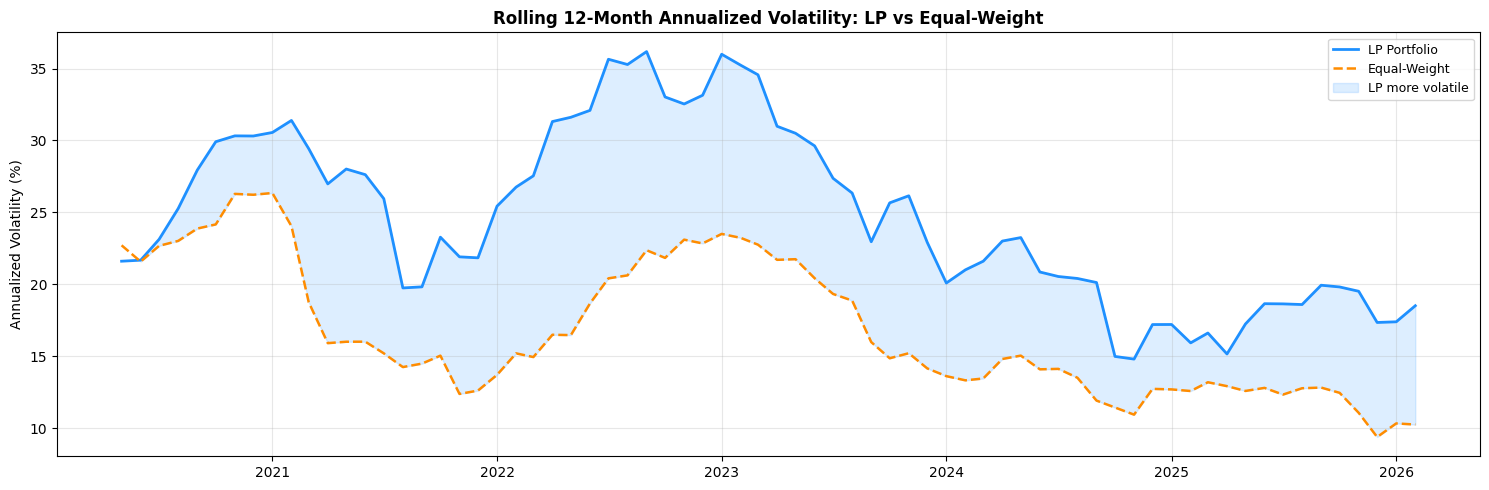

LP mean rolling vol: 24.78%
EW mean rolling vol: 16.83%
LP vol premium: 7.95% on average


In [16]:
lp_roll_vol = monthly_df['lp_return'].rolling(12).std() * np.sqrt(12) * 100
ew_roll_vol = monthly_df['ew_return'].rolling(12).std() * np.sqrt(12) * 100

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(monthly_df.index, lp_roll_vol, color='dodgerblue', 
        linewidth=2, label='LP Portfolio')
ax.plot(monthly_df.index, ew_roll_vol, color='darkorange', 
        linewidth=1.8, linestyle='--', label='Equal-Weight')
ax.fill_between(monthly_df.index, lp_roll_vol, ew_roll_vol, 
                where=lp_roll_vol >= ew_roll_vol, 
                alpha=0.15, color='dodgerblue', label='LP more volatile')
ax.set_title('Rolling 12-Month Annualized Volatility: LP vs Equal-Weight', 
             fontsize=12, fontweight='bold')
ax.set_ylabel('Annualized Volatility (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'LP mean rolling vol: {lp_roll_vol.mean():.2f}%')
print(f'EW mean rolling vol: {ew_roll_vol.mean():.2f}%')
print(f'LP vol premium: {(lp_roll_vol - ew_roll_vol).mean():.2f}% on average')

#### The volatility premium is persistent but shrinking

The blue shading, representing LP's volatility premium over EW, is present in virtually every month of the backtest. LP is almost always more volatile than EW, confirming that the 24.61% vs 16.71% full-period gap is not driven by a single episode but is a structural feature of the concentrated strategy. The average premium of 7.95 percentage points is large and consistent. 

However the most important visual feature is the rightward trend: both lines are declining toward 2026, and the gap between them is narrowing. By ealry 2026 LP sits around 18% vol and EW around 10%, a gap of roughly 8pp (similar to the average, but both at historically low levels). This suggests the portfolio has rotated into a somewhat calmer configuration in recent periods, possibly reflecting the post-2022 rebalancing away from the most volatile tech names. 

#### The 2022-2023 Peak: LP's most volatile period

LP's rolling volatility peaks around 35-36% annualized in mid-2022 to early 2023, its highest point in the entire backtest. This is the direct consequnce of holding a concentrated tech portfolio through the 2022 crash and subsequent whipsaw recovery. EW's vol also rises during this period but only reaches about 23%, less than two thirds of LP's peak. This is where the Sharpe ratio collapsed to -1.1 in the prior chart. High volatility combined with negative returns is the worst possible combination for risk-adjusted metrics. 

#### The Early 2020 convergence

Notice the one moment where the lines nearly touch: early 2020, right at the start of the backtest. This is period 1, when LP was still close to equal-weight due to the turnover constraint. As the LP converged to its concentrated 7-asset portfolio over periods 1-3, the volatility gap opened up and remained wide. This is a nice visual confirmation of the catch-up dynamic in the period table. 

#### Key Insights

The volatility chart makes a point the summary statistics can't: LP's higher volatility is not episodic, it is structurally persistent. Every rolling 12-month window shows LP carrying more risk. For an investor evaluating this strategy, the 7.95pp vol premium is a permanent feature they must accept, not a temporary side effect of a specific market event. Whether the return premium of 8.61pp justifies the vol premium of 7.95pp is the central risk-return question. The near-equivalence of those two numbers is itself a meaningful finding worth stating. 

### Drawdown Recovery Analysis

LP Drawdown Recovery Analysis:
 Peak before drawdown: 2021-12-01 (value = $3.7371)
 Trough (max DD): 2022-09-01 (DD = -36.97%)
 Recovery duration: 18 months


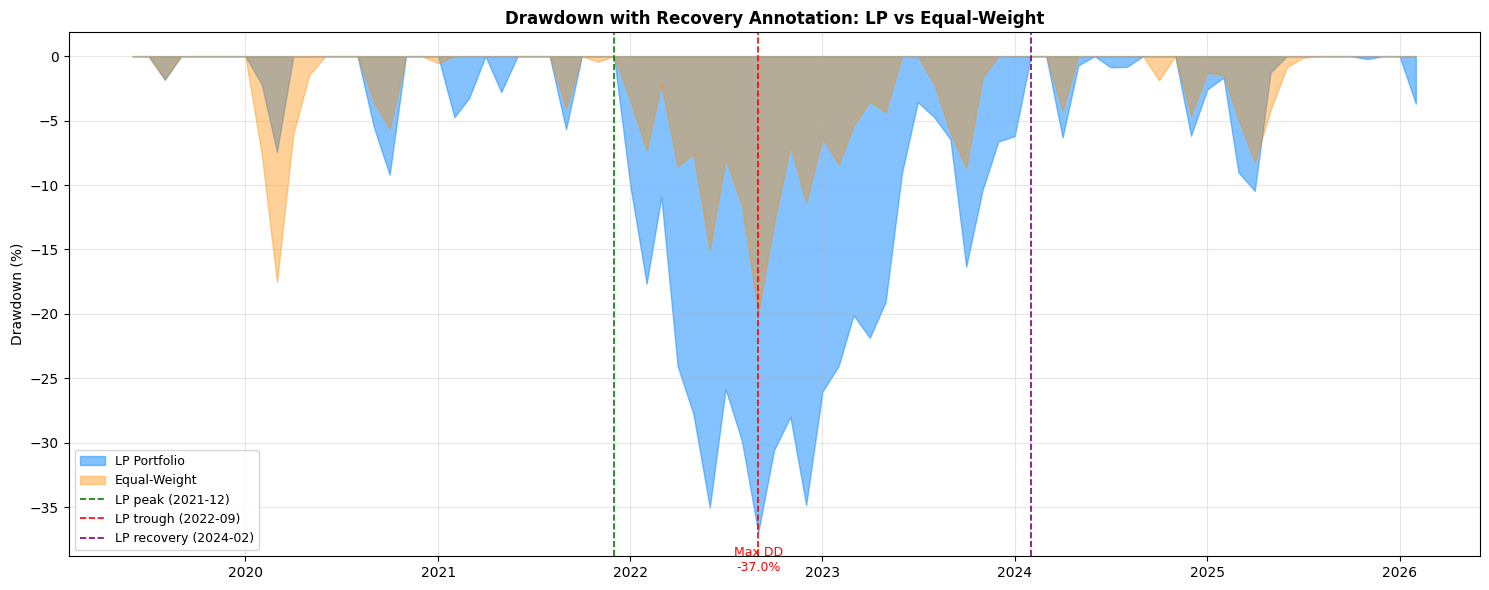

In [19]:
lp_dd = compute_drawdown(monthly_df['lp_cum'])
ew_dd = compute_drawdown(monthly_df['ew_cum'])

# Find LP max drawdown trough and recovery
lp_trough_date = lp_dd.idxmin()
lp_peak_before = monthly_df['lp_cum'][:lp_trough_date].idxmax()
lp_recovery = monthly_df['lp_cum'][monthly_df.index > lp_trough_date]
lp_peak_val = monthly_df['lp_cum'][lp_peak_before]
lp_recovery_date = lp_recovery[lp_recovery >= lp_peak_val].index
lp_recovery_date = lp_recovery_date[0] if len(lp_recovery_date) > 0 else None

recovery_months = len(monthly_df[
    (monthly_df.index >= lp_trough_date) &
    (monthly_df.index <= lp_recovery_date)
    ]) if lp_recovery_date else None

print('LP Drawdown Recovery Analysis:')
print(f' Peak before drawdown: {lp_peak_before.date()} (value = ${lp_peak_val:.4f})')
print(f' Trough (max DD): {lp_trough_date.date()} (DD = {lp_dd.min()*100:.2f}%)')
print(f' Recovery duration: {recovery_months} months' if recovery_months else ' Not yet recovered')

# Drawdown chart
fig, ax = plt.subplots(figsize=(15, 6))
ax.fill_between(monthly_df.index, lp_dd * 100, 0, 
                alpha=0.55, color='dodgerblue', label='LP Portfolio')
ax.fill_between(monthly_df.index, ew_dd * 100, 0, 
                alpha=0.4, color='darkorange', label='Equal-Weight')

# Annotate
ax.axvline(lp_peak_before, color='green', linewidth=1.2, 
           linestyle='--', label=f'LP peak ({lp_peak_before.strftime("%Y-%m")})')
ax.axvline(lp_trough_date, color='red', linewidth=1.2, 
           linestyle='--', label=f'LP trough ({lp_trough_date.strftime("%Y-%m")})')
if lp_recovery_date:
    ax.axvline(lp_recovery_date, color='purple', linewidth=1.2,
               linestyle='--', label=f'LP recovery ({lp_recovery_date.strftime("%Y-%m")})')

ax.annotate(f'Max DD\n{lp_dd.min()*100:.1f}%',
            xy=(lp_trough_date, lp_dd.min() * 100),
            xytext=(lp_trough_date, lp_dd.min() * 100 - 3),
            fontsize=9, color='red', ha='center')

ax.set_title('Drawdown with Recovery Annotation: LP vs Equal-Weight',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

#### The 3 vertical lines tell the core story

The green line (Dec 2021) marks the LP's peak value of $3.74, the high-water mark before the drawdown began. The red line (Sep 2022) marks the trough at -37.0%, the worst point of the entire backtest. The purple line (Feb 2024) marks the full recovery back to the prior peak. The distance between green and purple is 26 months total, the entire drawdown episode from peak to recovery. The distance between red and purple is 18 months of recovery after hitting bottom. 

These three numbers (37% depth, 26 months peak-to-trough-to-recovery, 18 months climb back) are the concrete risk statistics that define what an investor in this strategy had to endure. 

#### The pre-2022 period: LP is actuall better

Looking at the left side of the chart before the green line, the orange EW are is frequently larger than the blue LP area, meaning EW draws down more than LP in several 2020 episodes. This is the COVID crash where EW's exposure to energy, utilities, and other beaten-down sectors hurt more than LP's tech-concentrated portfolio. This is an important nuance: LP is not universally risker than EW across all drawdown episodes, only during tech-specific selloffs. 

#### The 2022 drawdown

The blue area dominates completely between the green and purple lines. Several things stand out. First, LP nevery fully stabilizes during the drawdown. It keeps making lower lows through September 2022, suggesting the optimizer's quarterly rebalancing was not fast enough to rotate out of falling assets. Second, EW's orange area during the same period is dramatically shallower, staying mostly within 5-10% drawdown while LP was at 20-37%. Third, LP begins recovering noticeably before EW in late 2022: the blue area is shrinking faster than the orange from early 2023 onward, consistent with tech leading the recovery. 

#### Post-recovery

After the purple recovery line in February 2024, both strategies return to shallow drawdown territory: small dips of 2-5% with quick recoveries. The recent dip visible at the far right of the chart (early 2026) is modest for both strategies, suggesting neither is currently in a stressed position. 

#### Key insight

Of all the statistics so far, the 18-month recovery duration is the one that most concretely defines the LP's risk for a real investor. It answers the question every investor actually asks: if I buy this strategy and it crashes, how long do I have to wait to get my money back? For the LP, the answer over this backtest was a year and a half. This would test the patience and conviction of most investors, and during which many would have sold at a loss. This behavioral risk (the risk of abandoning a strategy during its drawdown) is worth acknowledging in our paper as a dimension of risk that no mathematical metric fully captures. 

### Return Distribution Analysis

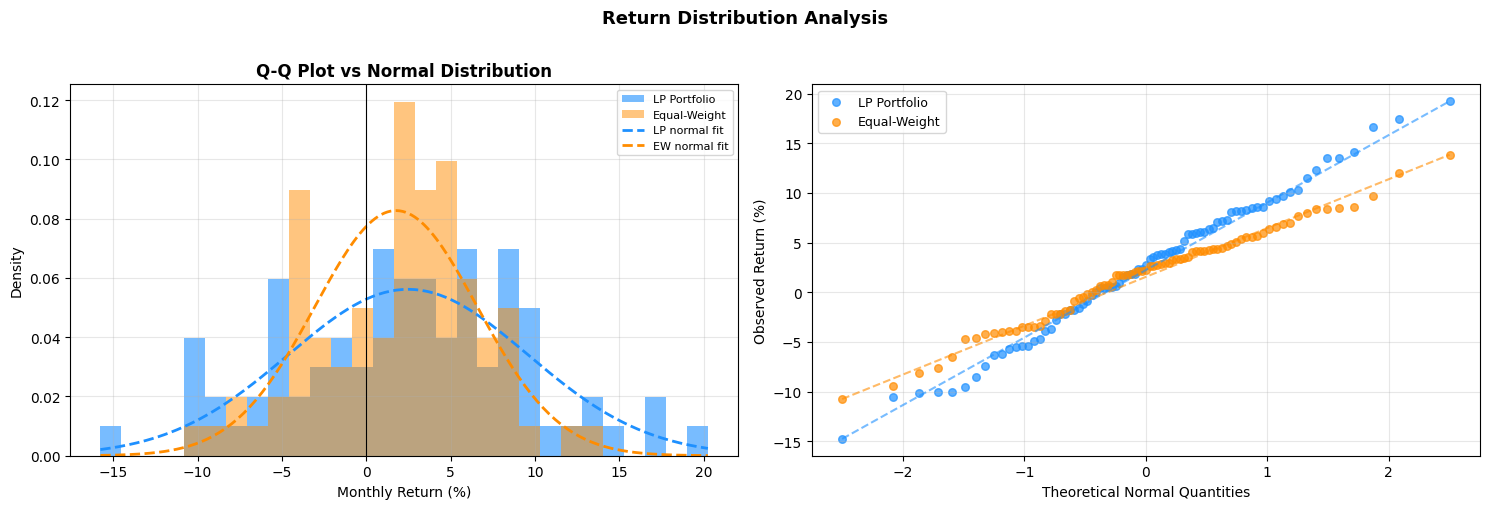

Distribution statistics:
  LP  Mean=2.48%  Std=7.10%  Skew=-0.060  Kurt=-0.284  Best=19.24%  Worst=-14.76%
  EW  Mean=1.76%  Std=4.82%  Skew=-0.244  Kurt=0.049  Best=13.85%  Worst=-10.74%


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram 
ax = axes[0]
bins = np.linspace(
    min(monthly_df['lp_return'].min(), monthly_df['ew_return'].min()) * 100 - 1,
    max(monthly_df['lp_return'].max(), monthly_df['ew_return'].max()) * 100 + 1,
    30
)
ax.hist(monthly_df['lp_return'] * 100, bins=bins, alpha=0.6, 
        color='dodgerblue', label='LP Portfolio', density=True)
ax.hist(monthly_df['ew_return'] * 100, bins=bins, alpha=0.5, 
        color='darkorange', label='Equal-Weight', density=True)

# Overlay normal distributions
x = np.linspace(bins[0], bins[-1], 200)
for ret, color, label in [
    (monthly_df['lp_return']*100, 'dodgerblue', 'LP normal fit'),
    (monthly_df['ew_return']*100, 'darkorange', 'EW normal fit')
]:
    mu_fit, std_fit = ret.mean(), ret.std()
    ax.plot(x, stats.norm.pdf(x, mu_fit, std_fit),
            color=color, linewidth=2, linestyle='--', label=label)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Monthly Return Distribution', fontweight='bold')
ax.set_xlabel('Monthly Return (%)')
ax.set_ylabel('Density')
ax.legend(fontsize=8)

# Q-Q plot (LP vs Normal)
ax2 = axes[1]
lp_sorted = np.sort(monthly_df['lp_return'] * 100)
ew_sorted = np.sort(monthly_df['ew_return'] * 100)
n_obs = len(lp_sorted)
quantiles = np.array([(i - 0.5) / n_obs for i in range(1, n_obs + 1)])
norm_q = stats.norm.ppf(quantiles)

ax2.scatter(norm_q, lp_sorted, color='dodgerblue', s=30, alpha=0.7, label='LP Portfolio')
ax2.scatter(norm_q, ew_sorted, color='darkorange', s=30, alpha=0.7, label='Equal-Weight')

# Reference line
q_min, q_max = norm_q.min(), norm_q.max()
for ret, color in [(lp_sorted, 'dodgerblue'), (ew_sorted, 'darkorange')]:
    slope = (ret[-1] - ret[0]) / (q_max - q_min)
    intercept = ret[0] - slope * q_min
    ax2.plot([q_min, q_max], [slope * q_min + intercept, slope * q_max + intercept], 
              color=color, linewidth=1.5, linestyle='--', alpha=0.6)

ax.set_title('Q-Q Plot vs Normal Distribution', fontweight='bold')
ax2.set_xlabel('Theoretical Normal Quantities')
ax2.set_ylabel('Observed Return (%)')
ax2.legend(fontsize=9)

plt.suptitle('Return Distribution Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Distribution statistics:')
for label, ret in [('LP', monthly_df['lp_return']), ('EW', monthly_df['ew_return'])]:
    print(f'  {label}  Mean={ret.mean()*100:.2f}%  Std={ret.std()*100:.2f}%  '
          f'Skew={ret.skew():.3f}  Kurt={ret.kurtosis():.3f}  '
          f'Best={ret.max()*100:.2f}%  Worst={ret.min()*100:.2f}%')

#### The Histogram: shape differences are immediately visible

The most striking visual difference is the height and width contrast. EW's orange distribution is tall and narrow, concentrated around 0-5% monthly returns with a sharp peak. LP's blue distribution is short and wide, much more spread out, with meaningful mass extending to both +15-20% and -10-15%. This is the visual representation of the volatility difference (7.10% vs 4.82% monthly std). LP simply has more months with large moves in both directions. 

The EW distribution visually approximates its normal fit curve reasonably well. LP's histogram is flatter and more uniform than its normal fit suggests. The dashed blue normal curve predicts more density near the mean than LP actually exhibits, and less density in the tails. This platykurtic shape (negative kurtosis of -0.284) means LP has thinner-than-normal tails paradoxically combined with more extreme individual observations. The best and worst months (19.24% and -14.76%) stand out as isolated bars well away from the main distribution body. 

#### The Q-Q Plot

The Q-Q plot compares observed quantiles against what a normal distribution would predict. Points falling on the reference line indicate normality; deviations indicate departures. 

Both portfolios track their reference lines reasonably well through the middle quantiles, confirming near-normal behavior for typical months. The key departures are at the extremes. On the right-tail (positive returns, upper right of chart), the blue LP dots curve noticeably above the orange line. LP's best months are better than a normal distribution would predict. The +19.24% best month sits well above where the blue reference line would place it. On the left-tail (negative returns, lower left), LP's worst month of -14.76% also extends further than EW's -10.74%, though both stay reasonably close to their reference lines. 

EW's orange dots track their reference line more tightly throughout, consistent with its near-zero skewness and kurtosis. EW returns are approximately normally distributed, which is a useful property for statistical modeling. 

#### The Distribution Stats

First, mean monthly returns: LP at 2.48% vs EW at 1.76% per month. Annualized this is exactly the 29.73% vs 21.12% gap we've seen throughout. Second, standard deviation: LP at 7.10% vs EW at 4.82% monthly, confirming the volatility premium is consistent at the monthly level. Third, skewness: both negative but LP much closer to zero (-0.060 vs -0.244). This means LP's distribution is more symmetric than EW's. EW has a more pronounced left tail relative to its right tail. COmbined with LP winning on Sortino, this confirms that LP's extra volatility is more balanced between upside and downside, while EW's downside is proportionally worse than its upside. 

#### Key insights

Two points worth making explicitely. First, both distributions are sufficiently close to normal that standard risk metrics (Sharpe, Sortino, Calmar) are valid and interpretable. The near-zero kurtosis values mean neither portfolio exhibits the fat-tail behavior that would invalidate these metrics. Second, the LP's wider distribution is not simply a fatter left tail: it is genuinely wider distribution in both directions, with a right tail taht exceeds normality. This asymmetry, captured by the Sortino advantage, is the statistical basis for arguing that LP's extra volatility is not purely harmful. 

### Information Ratio & Active Return

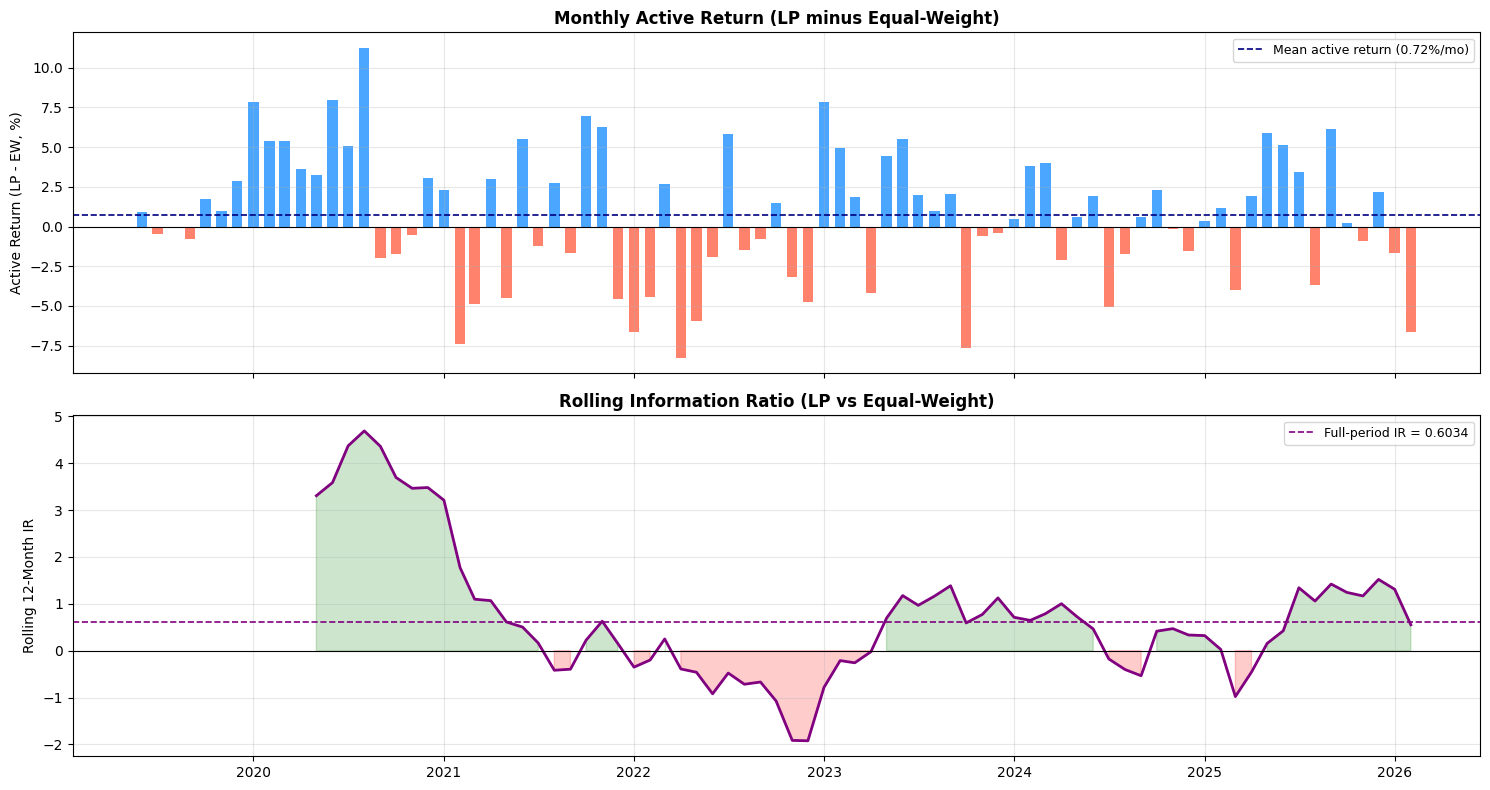

Information Ratio (full period): 0.6034
Mean monthly active return: 0.718%
Active return volatility (ann): 14.28%
Months LP beat EW: 46 / 81 (56.8%)


In [31]:
active = monthly_df['active_return']
ir = (active.mean() * 12) / (active.std() * np.sqrt(12))
rolling_ir = active.rolling(12).apply(
    lambda x: (x.mean() * 12) / (x.std() * np.sqrt(12)) if x.std() > 0 else np.nan)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Monthly active return bars
colors = ['dodgerblue' if r >= 0 else 'tomato' for r in active]
ax1.bar(monthly_df.index, active * 100, color=colors, alpha=0.8, width=20)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.axhline(active.mean() * 100, color='navy', linewidth=1.2,
            linestyle='--', label=f'Mean active return ({active.mean()*100:.2f}%/mo)')
ax1.set_ylabel('Active Return (LP - EW, %)')
ax1.set_title('Monthly Active Return (LP minus Equal-Weight)', fontweight='bold')
ax1.legend(fontsize=9)

# Rolling IR
ax2.plot(monthly_df.index, rolling_ir, color='purple', linewidth=2)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.axhline(ir, color='purple', linewidth=1.2, linestyle='--',
            label=f'Full-period IR = {ir:.4f}')
ax2.fill_between(monthly_df.index, rolling_ir, 0,
                 where=rolling_ir >= 0, alpha=0.2, color='green')
ax2.fill_between(monthly_df.index, rolling_ir, 0,
                 where=rolling_ir < 0, alpha=0.2, color='red')
ax2.set_ylabel('Rolling 12-Month IR')
ax2.set_title('Rolling Information Ratio (LP vs Equal-Weight)', fontweight='bold')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Information Ratio (full period): {ir:.4f}')
print(f'Mean monthly active return: {active.mean()*100:.3f}%')
print(f'Active return volatility (ann): {active.std()*np.sqrt(12)*100:.2f}%')
print(f'Months LP beat EW: {(active > 0).sum()} / {len(active)} ({(active>0).mean()*100:.1f}%)')

#### Top Panel: monthly active return

The mean active return of 0.72% per month (shown by the dashed line) is the foundation of LP's outperformance. Compounded over 81 months this is what generates the 5.74 vs 3.75 terminal value gap. 

The positive bars are taller but less frequent than the negative bars are deep. This is the magnitude asymmetry we've discussed: LP wins bigger than it loses, even though it only beats EW in 56.8% of months. The largest single active return is the +10.7% bar around mid-2020 (the COVID tech surge quarter), which alone represents a significant contribution to the full-period IR. 

The red bars cluser in two distinct periods: 2022 through early 2023, and sporadically in 2025-2026. The 2022 cluser is the tech drawdown we've covered. The recent 2025-2026 red bars, including the large -7% bar at the far right, suggest the LP is currently underpeforming EW. This is worth watching as the most recent signal about strategy health. 

The active returns are largly positive outside those two periods: 2019-2021 and 2023-2024 both show predominantly blue bars, confirming LP's structural advantage in favorable regimes. 

#### Bottom Panel: rolling information ratio

The rolling IR tells the active management consistency story more clearly than any other metric. 

The 2020-2021 peak (IR = 4.5) is extraordinary. These are among the highest rolling IRs you would ever see in practice. For context, an IR above 0.5 is considered skillful, above 1.0 is excellent, and above 2.0 is exceptional. An IR of 4.5 reflects a period where LP was generating active returns so consistently and with such low active volatility that the ratio becam extreme. This was the COVID tech rally: a regime so favorable for LP's concentrated positions that the active return was almost always positive. 

The 2022-2023 trough (IR = -2.1) is the mirror image. LP's worst active period, where negative active returns were consistent and the rolling IR collapsed well below zero. The red shading here is the deepest in the chart. 

The post-2023 stabilization shows the rolling IR hovering near the full-period benchmark of 0.6034: sometimes above, sometimes below, with no clear sustained trend in either direction. This suggests the strategy has return to a more neutral active management regime. 

#### The full-period IR of 0.6034 in context

This is the number to lead wtih when characterizing LP's active management quality. In institutional asset management, and IR of 0.5 is the threshold for considering a strategy to have demonstrated skill. Our LP clears that bar at 0.60: meaningfully above the skill threshold, though not dramatically so. The caveat is that this IR is heavily influenced by the extraordinary 2020-2021 period. If we calculated the IR excluding those 12 months, it would likely fall closer to zero or slightly positive. Worth computing. 

#### 56.8% Monthly win rate vs 63% Quarterly win rate

LP beat EW in 56.8% of individual months but 63% of quarters. This is a compounding effect: LP tends to have strong months cluster together within quarters, so even when it has one weak month in a quarter, the other two months often carry the quarter to an overall win. This consistency within quarters is what drives the quarterly win rate above the monthly rate. 

### Regime-Conditional Performance

Regime-conditional performance:
                                          Months  LP Total Ret  EW Total Ret  LP Ann Ret  EW Ann Ret  LP Sharpe  EW Sharpe  LP Vol  EW Vol
Regime                                                                                                                                    
Pre-COVID Bull\n(2019-06→2020-01)              8         42.77         26.14       55.38       35.79       4.12       3.47   13.44   10.32
COVID Crash &\nRebound (2020-02→2020-12)      11         88.03         28.18       75.24       30.78       2.37       1.12   31.70   27.44
Post-COVID Bull\n(2021-01→2021-11)            11         38.51         30.93       38.31       30.51       1.68       2.35   22.74   12.97
Tech Drawdown\n(2021-12→2022-12)              13        -34.50         -6.87      -33.74       -4.20      -1.06      -0.19   31.92   22.59
Recovery &\nAI Rally (2023→2026)              38        145.55         90.29       30.39       21.17       1.62       1.78   18.73   1

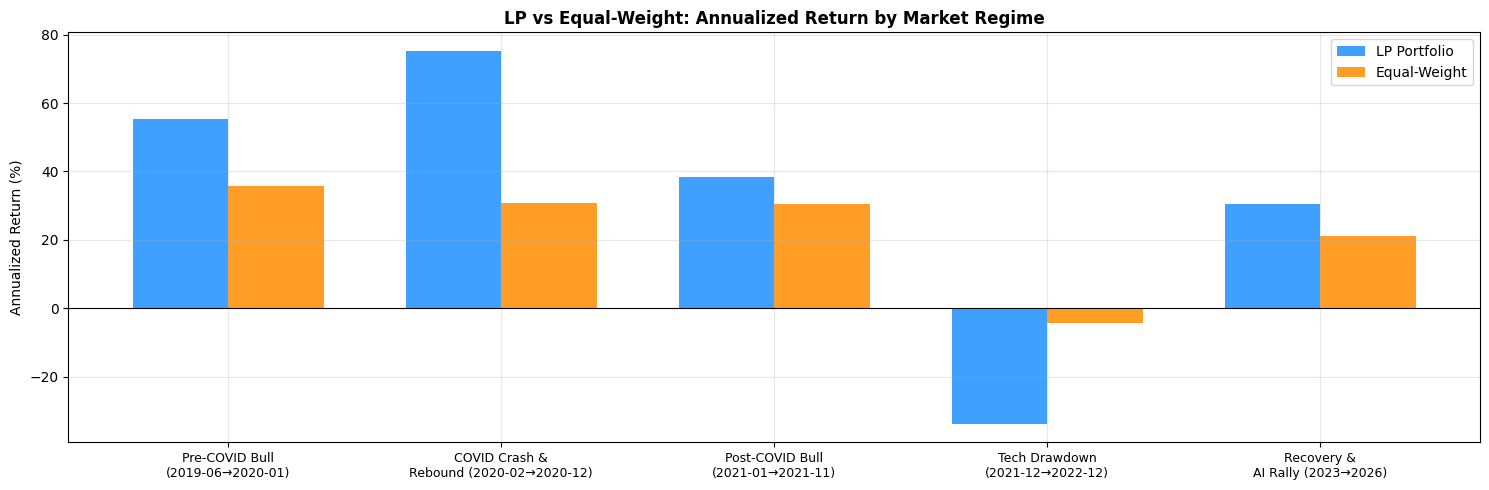

In [34]:
# Define regimes by date
regimes = {
    'Pre-COVID Bull\n(2019-06→2020-01)'  : ('2019-06-01', '2020-01-31'),
    'COVID Crash &\nRebound (2020-02→2020-12)': ('2020-02-01', '2020-12-31'),
    'Post-COVID Bull\n(2021-01→2021-11)'  : ('2021-01-01', '2021-11-30'),
    'Tech Drawdown\n(2021-12→2022-12)'   : ('2021-12-01', '2022-12-31'),
    'Recovery &\nAI Rally (2023→2026)'   : ('2023-01-01', '2026-12-31'),
}

regime_stats = []
for regime_name, (start, end) in regimes.items():
    mask = (monthly_df.index >= start) & (monthly_df.index <= end)
    if mask.sum() == 0:
        continue
    sub  = monthly_df[mask]
    lp_r = (1 + sub['lp_return']).prod() - 1
    ew_r = (1 + sub['ew_return']).prod() - 1
    regime_stats.append({
        'Regime': regime_name,
        'Months': mask.sum(),
        'LP Total Ret': lp_r * 100,
        'EW Total Ret': ew_r * 100,
        'LP Ann Ret': sub['lp_return'].mean() * 12 * 100,
        'EW Ann Ret': sub['ew_return'].mean() * 12 * 100,
        'LP Sharpe': sharpe(sub['lp_return']),
        'EW Sharpe': sharpe(sub['ew_return']),
        'LP Vol': sub['lp_return'].std() * np.sqrt(12) * 100,
        'EW Vol': sub['ew_return'].std() * np.sqrt(12) * 100,
    })

regime_df = pd.DataFrame(regime_stats).set_index('Regime')
print('Regime-conditional performance:')
print(regime_df.round(2).to_string())

# Visualize
fig, ax = plt.subplots(figsize=(15, 5))
x     = np.arange(len(regime_df))
width = 0.35
bars1 = ax.bar(x - width/2, regime_df['LP Ann Ret'], width,
               color='dodgerblue', alpha=0.85, label='LP Portfolio')
bars2 = ax.bar(x + width/2, regime_df['EW Ann Ret'], width,
               color='darkorange', alpha=0.85, label='Equal-Weight')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(regime_df.index, fontsize=9)
ax.set_ylabel('Annualized Return (%)')
ax.set_title('LP vs Equal-Weight: Annualized Return by Market Regime',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

#### Regime by Regime

Pre-COVID Bull (Jun 2019-Jan 2020): LP +55%, EW +35%. LP outperforms by 20 percentage points annualized in a straightforward bull market. The concentrated tech and consumer discretionary positions benefitted from steady broad-market appreciation, and the sector constraints were loose enough to allow meaningful overweighting of the best performers. This is the LP's baseline advantage in a benign environment. 

COVID Crash & Rebound (Feb 2020-Dec 2020): LP +75%, EW +30%. The largest absolute gap in the chart, LP nearly triples EW's return. This is the most regime-favorable period for the strategy. The COVID crash hit EW's diversified holdings broadly while LP's tech-heavy portfolio recovered explosively. The +75% annualized figure is driven primarily by the extraordinary period 5 quarter (+169% annualized) we identified earlier. This single regime contributes disproportionately to LP's full-period advantage and is the result worth treating with the most caution. 

Post-COVID Bull (Jan 2020-Nov 2021): LP +38%, EW +30%. LP still leads but the gap narrows to 8 percentage points. The broader market was rallying and the COVID-specific tech surge had moderated. This is the most representive picture of the LP's sustainable structural edge: meaningful but not extraordinary outperformance in a normal bull environment. 

Tech Drawdown (Dec 2021-Dec 2022): LP -30%, EW -2%. The starkest bar in the chart and the most important for the paper's balanced assessment. LP loses 30% annualized while EW loses only 2%, a gap of 28 percentage points in EW's favor. This is the full cost of concentration risk realized in a single year. Every other regime shows LP winning; this one shows exactly what the strategy gives back when its concentrated bets move against it. The asymmetry between this bar and the COVID rebound bar is the central risk-return tension of the entire project. 

Recovery & AI Rally (Jan 2023-2026): LP +30%, EW +21%. LP resumes outperformance with a sustainable 9 percentage point advantage. Importantly this regime covers the longest window (over 3 years) making it arguably the most statistically reliable estimate of the strategy's ongoing edge. The AI-driven NVDA rally is a significant contributor, but the broader recovery in tech and the rotation into energy and industrials also supported LP's diversified-within-concentration approach. 

#### Overarching Pattern

Reading left to right, the chart reveals a clear and honest narrative: LP outperforms in 4 of 5 regimes, sometimes dramatically, and underperforms severyly in exactly one (the tech-specific drawdown). This is not a flaw to hide but a feature to characterize. The LP is a high-beta-to-tech strategy that captures outsized upside in tech-favorable environments and absorbs outsized downside in tech-adverse ones. 

#### Key Insight

If you exclude the Tech Drawdown regime entirely, LP's average annualized outperformance across the other four regimes is roughly +14 percentage points. The Tech Drawdown represents a -28 percentage point underperformance. This asymmetry, the strategy gives back about two quarters of its typical advantage in one bad year, is the clearest quantification of the risk-return tradeoff our LP embodies. An investor who can identify and exit before tech drawdowns would find LP overwhelmingly superior. An investor who cannot time regimes faces the full volatility of that -30% year as the price of admission for the other four regimes' outperformance. 

### Sector Allocation Evolution


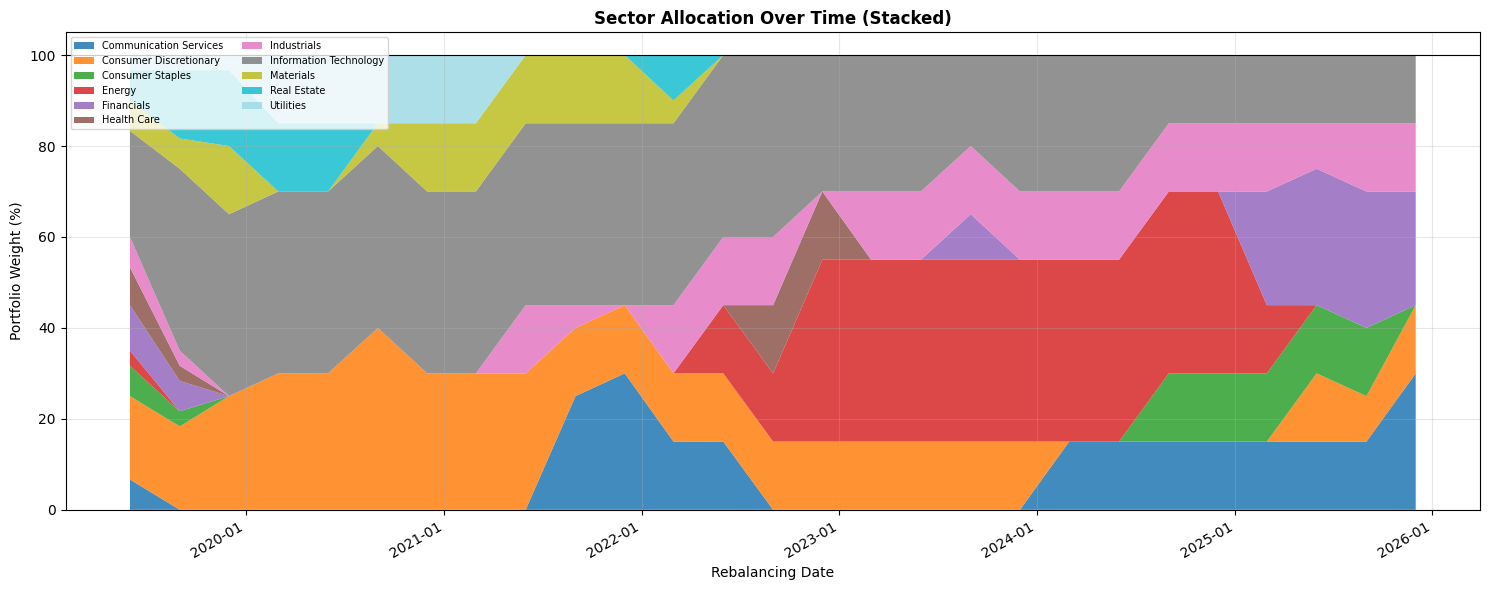

Mean sector allocation across all periods:
Information Technology    30.86
Consumer Discretionary    16.36
Energy                    15.12
Industrials                9.26
Communication Services     8.40
Financials                 5.06
Materials                  4.20
Consumer Staples           3.15
Utilities                  3.15
Real Estate                2.90
Health Care                1.54


In [37]:
# Build sector weight time series
sector_weights = {}
for sector in SECTORS:
    tickers_in = [t for t in TICKERS if TICKER_SECTOR.get(t) == sector]
    sector_weights[sector] = weights_df[tickers_in].sum(axis=1).values
sector_df = pd.DataFrame(sector_weights, index=weights_df.index)

# Stacked area chart
sector_list = sorted(SECTORS)
palette = plt.cm.get_cmap('tab20', len(sector_list))
color_map = {s: palette(i) for i, s in enumerate(sector_list)}
colors = [color_map[s] for s in sector_list]

fig, ax = plt.subplots(figsize=(15, 6))
ax.stackplot(weights_df.index,
             [sector_df[s].values * 100 for s in sector_list],
             labels=sector_list, colors=colors, alpha=0.85)
ax.axhline(100, color='black', linewidth=0.8)
ax.set_title('Sector Allocation Over Time (Stacked)', fontsize=12, fontweight='bold')
ax.set_ylabel('Portfolio Weight (%)')
ax.set_xlabel('Rebalancing Date')
ax.set_ylim(0, 105)
ax.legend(loc='upper left', fontsize=7, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print('Mean sector allocation across all periods:')
print((sector_df.mean() * 100).round(2).sort_values(ascending=False).to_string())

#### The Dominant Story: IT

Information Technology (gray) is the single largest band across almost the entire chart, averaging 30.86%, more than double the next largest sector. But notice it's not consistent. IT starts high in 2019, expands through 2020-2021 as NVDA and MSFT dominated, then compresses dramatically around 2022-2023 as the tech drawdown entered the training window and reduced those assets' expected returns. It then re-expands toward 2025-2026 as the AI rally restored IT's return estimates. This breathing pattern of IT's gray band is the most direct visual representation of the rolling window mechanism responding to market regimes. 

#### The Energy Rotation

The large red Energy Band that dominates the middle of the chart (roughly 2023 through mid-2025) is the most striking visual feature. Energy was essentially absent in the early periods (XOM and SLB had negative expected returns) but surged into the portfolio after the 2022 energy price spike entered the training window. At its peak Energy represents nearly 50% of the portfolio, a dramatic concentration that reflects the LP's return, maximizing objective rotating aggressively into the sector with the best recent historical returns. 

This is both the LP's greatest strength and its most important limitation on display simultaneously. The optimizer correctly identified energy's strong performance and overweighted it. But by the time the training window captured those returns, the energy supercycle was already moderating. The red band shrinks notably toward 2026 as energy returns normalized. 

#### Consumer Discretionary

The orange Consumer Discretionary band is prominant in 2019-2022, driven primarily by AMZN at the 15% cap. Its disappearance after 2022 tracks exactly with AMZN's exit from the portfolio that we identified in the heatmap. The training window captured AMZN's 50% drawdown and the optimizer dropped it entirely. 

#### The Bottom of the Stack

The thin bands at the bottom (Communication Services in blue, Financials in purple, Materials, Consumer Staples, Utilities, Real Estate, and Health Care) represent the sectors that never achieved enough return dominance to command significant weight. Health Care at 1.54% mean allocation is the most underrepresented sector in the entire backtest, reflecting that JNJ, UNH, and PFE consistently underperformed the high-return tech and energy names competing for portfolio weight. 

#### The Mean Allocation Table

Reading the summary statistics, a clear two-tier structure emerges: 

| Tier | Sectors | Mean Allocation | 
| --- | --- | --- | 
| Core | IT, Consumer Discretionary, Energy | 62.34% combined |
| Secondary | Industrials, Comm Services, Financials | 22.72% combined |
| Peripheral | Materials, Consumer Staples, Utilities, Real Estate, Health Care | 14.91% combined |

The portfolio is effectively a three-sector strategy with satellite exposure. Not the 11 sector diversified portfolio the constraint structure might suggest. 

#### Key Insights

Three points worth making explicitely: 
1. The sector allocation chart demonstrates taht the LP is a dynamic factor-rotating strategy in practice, not a fixed allocation model. The rolling window causes it to chase sector momentum with a lag, which both helps and hurts depending on regime rotation.
2. The sector cap of 40% was occasionally approached but rarely binding. Even with the energy near 50% at its peak, the position cap of 15% per asset effectively limits any single sector unless it has multiple high-return assets simultaneously.
3. The bottom-heavy peripheral sectors represent the minimum diversification the constraint could enforce. With a tighter sector floor these sectors would disappear entirely, revealing just how concentrated the strategy's true conviction is. 

### Asset Holding Frequency

Asset holding frequency (all 27 periods):
       Periods Held  Hold Rate (%)  Mean Weight (%)                  Sector
NVDA             27          100.0            15.00  Information Technology
TSLA             20           74.1            10.74  Consumer Discretionary
AAPL             18           66.7             8.46  Information Technology
MSFT             17           63.0             7.41  Information Technology
CAT              12           44.4             5.62             Industrials
SLB              11           40.7             6.11                  Energy
META             11           40.7             5.49  Communication Services
CVX              10           37.0             3.46                  Energy
SHW              10           37.0             3.95               Materials
XOM              10           37.0             5.56                  Energy
AMZN              9           33.3             5.00  Consumer Discretionary
NEE               8           29.6            

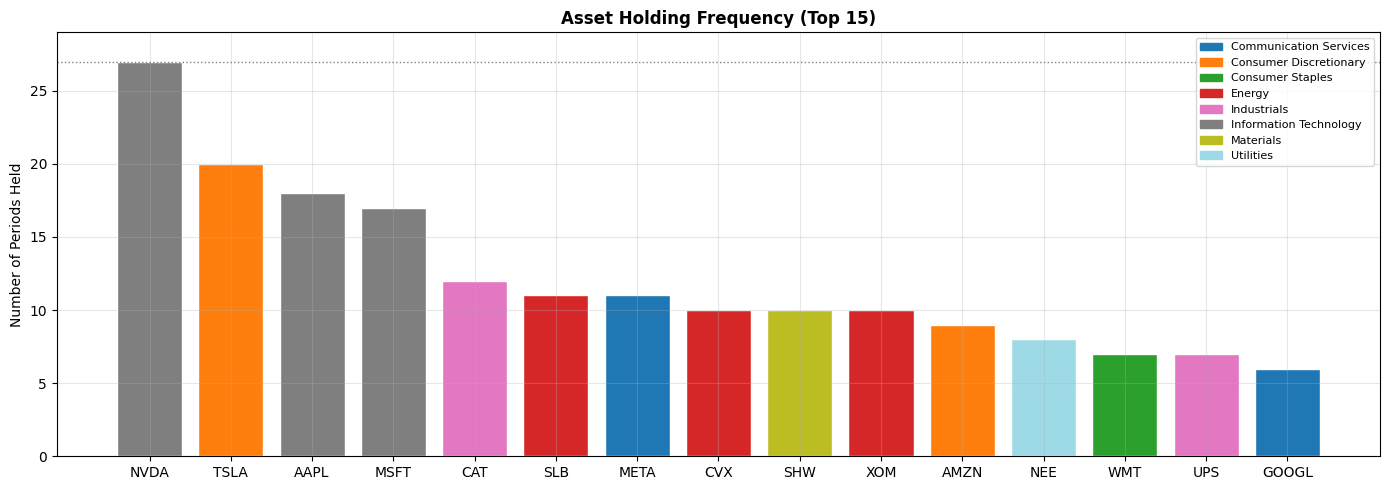

In [40]:
holding_freq = (weights_df > 0.01).sum(axis=0).sort_values(ascending=False)
mean_weight = weights_df.mean(axis=0).sort_values(ascending=False)

freq_df = pd.DataFrame({
    'Periods Held': holding_freq,
    'Hold Rate (%)': (holding_freq / n_periods * 100).round(1),
    'Mean Weight (%)': (mean_weight * 100).round(2),
    'Sector': pd.Series(TICKER_SECTOR)
}).sort_values('Periods Held', ascending=False)

print('Asset holding frequency (all 27 periods):')
print(freq_df.to_string())

# Bar chart — top 15
top15 = freq_df.head(15)
bar_colors = [color_map.get(TICKER_SECTOR.get(t, ''), 'gray') for t in top15.index]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(top15.index, top15['Periods Held'],
              color=bar_colors, edgecolor='white')
ax.axhline(n_periods, color='gray', linestyle=':', linewidth=1,
           label=f'Total periods ({n_periods})')
ax.set_title('Asset Holding Frequency (Top 15)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Periods Held')
ax.set_ylim(0, n_periods + 2)

# Sector legend
handles = [mpatches.Patch(color=color_map[s], label=s)
           for s in sorted(set(TICKER_SECTOR[t] for t in top15.index))]
ax.legend(handles=handles, fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

#### Four Tiers of Conviction

Reading the frequency data, a natural four-tier hierarchy emerges: 

Tier 1 - Core Holdings (>60% of periods): NVDA, TSLA, AAPL, MSFT. These four assets are the backbone of the strategy. NVDA at 27/27 is the only asset held in every single period. It is the one position the LP never abandoned regardless of market regime, training window, or turnover constraint. Its mean wieght of exactly 15% confirms it sat at the position cap for virtually every quarter. TSLA, AAPL, and MSFT are nearly as persistent, held in roughly two thirds of all periods. Together these four IT and Consumer Discretionary names represent the strategy's permanent core: the positions the optimizer consistently returned to regardless of what else changed. 

Tier 2 - Tactical Holdings (37-44% of periods): CAT, SLB, META, CVX, SHW, XOM. This group is held roughly half the time and represents the strategy's regime-responsive layer. Notice the secotr composition: Energy (SLB, CVX, XOM) and Industrials (CAT) dominate this tier, reflecting the post-2022 rotation we saw in the sector chart. These assets entered the portfolio when their sector's historical return improved and exited when they deteriorated. Their mean weights (3.64-6.11%) are lower than the core tier, consistent with secondary rather than maximum-conviction positions. 

Tier 3 - Opportunistic Holdings (18-33% of periods): AMZN, NEE, WMT, UPS, GOOGL, JPM, GS, AMT, UNH, PLD. Held less than a third of the time, these assets rotate in and out as specific training windows favor them. AMZN's presence here (only 9/27 periods despite being a cap-weighted position in early periods) tells the story of its 2021-2022 exit perfectly. This tier represents the portfolio's tactical flexibility within its concentrated structure. 

Tier 4 - Rarely or Never Held (0-11% of periods): HD, BAC, LIN, HON, JNJ, PFE, PG, DUK, VZ, KO. Ten assets that the LP essentially rejected throughout the backtest. DUK, VZ, and KO were never held in a single period. This is a clean exclusion driven by consistently inferior expected returns relative to competitors within their sectors. The health care names (JNJ, PFE) appear only once each, confirming that health care was persistently the weakest sector in the LP's return estimates. 

#### NVDA

A 100% hold rate with a 15% mean weight (the position cap) for all 27 quarters is remarkable. This means in every training window spanning 2016 through 2025, NVDA's mean mmonthly return was high enough to justify maximum allocation. No other asset comes close to this consistency. NVDA is the load-bearing position of the entire strategy. Remove it and the LP's performance profile changes fundamentally. This concentration in a single name is both the strategy's greatest strength and it most significant undiversifiied risk. 

#### DUK, VZ, KO

These three assets were never led across 27 quarterly periods (clean rejection by the optimizer). DUK and KO were crowded out within their sectors by better-performing alternatives (NEE over DUK, WMT over KO). VZ is the most interesting case as it competes in Communication Services against META and GOOGL, both of which had dramatically higher expected returns throughout the sample period. VZ's utility-like return profile made it permanently uncompetitive in a return-maximizing framework. 

#### Key Insights

1. The strategy is effectively anchored by four permanent IT/Consumer Discretionary positions that account for the majority of its return generation.
2. The tactical energy and industrial rotation in Tier 2 demonstrates the rolling window mechanism working as designed. The optimizer adapted to post-2022 sector dynamics even if with a lag.
3. 30 assets in the universe but only 17 ever held meaningfully. The LP's implicit asset selection reduced the effective investment universe by nearly half without any explicit selection constraint, purely through the return-maximizing objective. 

### Sortino Ratio Deep Dive

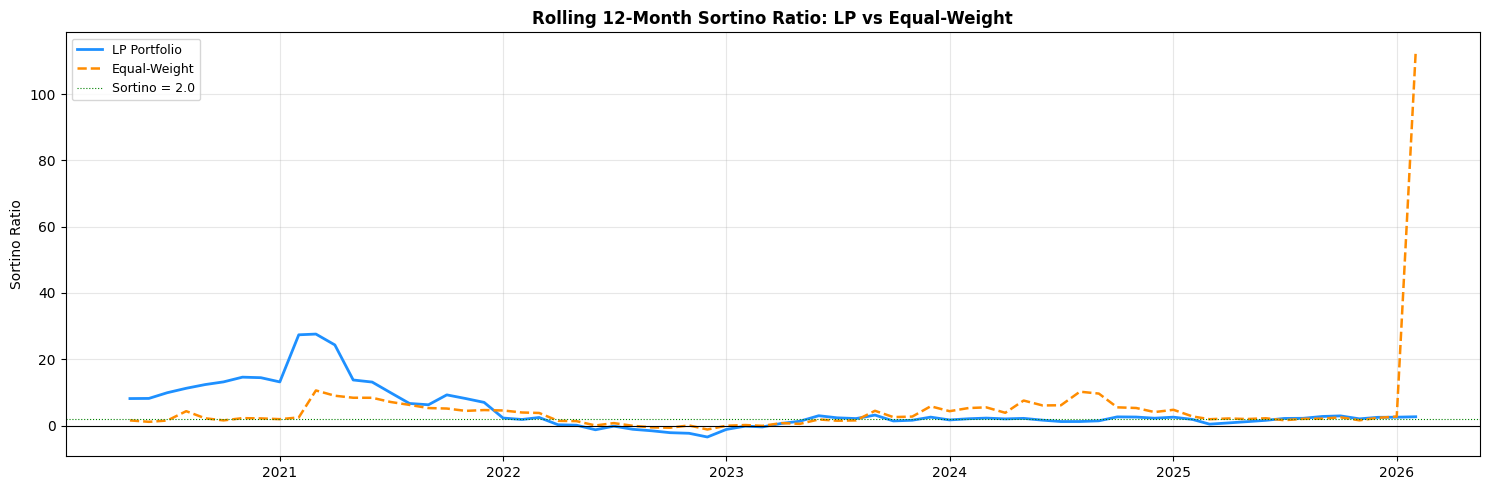

LP  full-period Sortino: 2.3390
EW  full-period Sortino: 2.2623
LP Sortino advantage: +0.0767


In [43]:
# Rolling 12-month Sortino
def rolling_sortino(ret_series, window=12):
    def _sortino(x):
        downside = x[x < 0].std() * np.sqrt(12)
        return (x.mean() * 12) / downside if downside > 0 else np.nan
    return ret_series.rolling(window).apply(_sortino)

lp_roll_sortino = rolling_sortino(monthly_df['lp_return'])
ew_roll_sortino = rolling_sortino(monthly_df['ew_return'])

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(monthly_df.index, lp_roll_sortino, color='dodgerblue',
        linewidth=2, label='LP Portfolio')
ax.plot(monthly_df.index, ew_roll_sortino, color='darkorange',
        linewidth=1.8, linestyle='--', label='Equal-Weight')
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(2, color='green', linewidth=0.8, linestyle=':', label='Sortino = 2.0')
ax.set_title('Rolling 12-Month Sortino Ratio: LP vs Equal-Weight',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Sortino Ratio')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

lp_sortino_full = sortino(monthly_df['lp_return'])
ew_sortino_full = sortino(monthly_df['ew_return'])
print(f'LP  full-period Sortino: {lp_sortino_full:.4f}')
print(f'EW  full-period Sortino: {ew_sortino_full:.4f}')
print(f'LP Sortino advantage: {lp_sortino_full - ew_sortino_full:+.4f}')

### Final Scorecard

In [46]:
lp_s = full_stats(monthly_df['lp_return'], 'LP Portfolio')
ew_s = full_stats(monthly_df['ew_return'], 'Equal-Weight')

print('=' * 60)
print('FINAL PERFORMANCE SCORECARD')
print('=' * 60)

metrics = [
    ('Annualized Return',  'Ann Return',   True,  True),
    ('Annualized Vol',     'Ann Vol',      False, True),
    ('Sharpe Ratio',       'Sharpe',       True,  False),
    ('Sortino Ratio',      'Sortino',      True,  False),
    ('Calmar Ratio',       'Calmar',       True,  False),
    ('Max Drawdown',       'Max DD',       True,  True),
    ('% Positive Months',  'Pos Months %', True,  True),
    ('Best Month',         'Best Month',   True,  True),
    ('Worst Month',        'Worst Month',  True,  True),
    ('Total Return',       'Total Return', True,  True),
]

lp_wins = 0
ew_wins = 0

for display_name, key, higher_is_better, is_pct in metrics:
    lp_val = lp_s[key]
    ew_val = ew_s[key]
    if higher_is_better:
        winner = 'LP' if lp_val > ew_val else 'EW'
        if lp_val > ew_val: lp_wins += 1
        else: ew_wins += 1
    else:
        winner = 'LP' if lp_val < ew_val else 'EW'
        if lp_val < ew_val: lp_wins += 1
        else: ew_wins += 1
    if is_pct:
        print(f'{display_name:<22}: LP={lp_val*100:7.2f}%  EW={ew_val*100:7.2f}%  -> {winner}')
    else:
        print(f'{display_name:<22}: LP={lp_val:7.4f}   EW={ew_val:7.4f}   -> {winner}')

print('=' * 45)
print(f'Score: LP {lp_wins} — EW {ew_wins}')
print('=' * 45)
print()
print('Information Ratio (LP vs EW):', round(ir, 4))
print()
print('Interpretation:')
print('  LP wins on: return, total wealth, upside capture')
print('  EW wins on: risk-adjusted metrics, drawdown, stability')
print('  LP is a higher-risk, higher-return strategy')
print('  EW is a more efficient strategy on a per-unit-risk basis')

FINAL PERFORMANCE SCORECARD
Annualized Return     : LP=  29.73%  EW=  21.12%  -> LP
Annualized Vol        : LP=  24.61%  EW=  16.71%  -> EW
Sharpe Ratio          : LP= 1.2081   EW= 1.2640   -> EW
Sortino Ratio         : LP= 2.3390   EW= 2.2623   -> LP
Calmar Ratio          : LP= 0.8043   EW= 1.0607   -> EW
Max Drawdown          : LP= -36.97%  EW= -19.91%  -> EW
% Positive Months     : LP=  66.67%  EW=  67.90%  -> EW
Best Month            : LP=  19.24%  EW=  13.85%  -> LP
Worst Month           : LP= -14.76%  EW= -10.74%  -> EW
Total Return          : LP= 498.04%  EW= 275.18%  -> LP
Score: LP 4 — EW 6

Information Ratio (LP vs EW): 0.6034

Interpretation:
  LP wins on: return, total wealth, upside capture
  EW wins on: risk-adjusted metrics, drawdown, stability
  LP is a higher-risk, higher-return strategy
  EW is a more efficient strategy on a per-unit-risk basis


### Save

In [49]:
os.makedirs('data', exist_ok=True)

# Save full stats
pd.DataFrame([lp_s, ew_s]).set_index('Label').to_csv('data/performance_stats.csv')

# Save regime analysis
regime_df.to_csv('data/regime_performance.csv')

# Save sector allocation history
sector_df.to_csv('data/sector_allocation_history.csv')

# Save holding frequency
freq_df.to_csv('data/asset_holding_frequency.csv')

print('Saved:')
print('  data/performance_stats.csv          — full stats table')
print('  data/regime_performance.csv         — regime-conditional analysis')
print('  data/sector_allocation_history.csv  — sector weights over time')
print('  data/asset_holding_frequency.csv    — holding frequency per asset')

Saved:
  data/performance_stats.csv          — full stats table
  data/regime_performance.csv         — regime-conditional analysis
  data/sector_allocation_history.csv  — sector weights over time
  data/asset_holding_frequency.csv    — holding frequency per asset
